In [61]:
# 引用库
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


In [2]:
!pip uninstall pandas


^C


In [22]:
!pip install --upgrade numpy pandas scipy


^C


In [83]:
# 数据处理
# pd 数据处理
import json

# n = 17914  # 设置要读取的行数
json_file = r'D:\PycharmProjects\TDFilter\experiment5\roberta\Radiation\results.jsonl'

# 逐行读取并解析前 n 行
data = []
# limit = 17579
with open(json_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        # if i>=limit:
        #     break
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError as e:
            print(f"JSONDecodeError at line {i}: {e}")
            continue

# 将结果转换为 DataFrame
import pandas as pd
df = pd.DataFrame(data)
print(f"数据集的大小: {len(df)}")
df.head()

数据集的大小: 72506


,knowledge,flag,confidence_flag,contradiction_flag,score_of_confidence,score_of_contradiction
0,Quantitative external counting and/or sampling...,1,1,-1,0.985119,0.967868
1,"In 2022, Shanghai had 992 institutions dedicat...",1,1,0,0.973455,0.907713
2,There was observed a dose-related increase in ...,1,1,-1,0.922489,0.556473
3,"Mental and psychological care, along with soci...",1,1,-1,0.968415,0.979063
4,The LCR values for 222Rn exposure were below I...,1,1,-1,0.792900,0.960309


In [84]:
# 提取有用的特征
X = df[['confidence_flag','score_of_confidence','contradiction_flag', 'score_of_contradiction']]
y = df['flag']  # 目标标签
y

0        1
1        1
2        1
3        1
4        1
        ..
72501    1
72502    1
72503    1
72504    1
72505    1
Name: flag, Length: 72506, dtype: int64

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.97, random_state=42)
X_train

,confidence_flag,score_of_confidence,contradiction_flag,score_of_contradiction
50057,1,0.780230,-1,0.988177
17015,1,0.969347,-1,0.866386
19675,1,0.548108,0,0.999393
34742,1,0.981248,-1,0.933039
162,1,0.842105,0,0.892630
...,...,...,...,...
37194,1,0.964573,-1,0.997798
6265,1,0.812762,1,0.992222
54886,1,0.875146,-1,0.644993
860,1,0.968938,-1,0.482206


In [86]:
'''
    log_loss:是交叉熵损失函数，适用于二分类问题，据说在需要高置信度的概率预测时，表现得很好
    max_depth:二分类问题中，通常3到5的深度就可以得到不错的效果。
    random_state:随机种子，保证每次运行结果一致
'''
clf = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=5,
    random_state=42
)

In [87]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=5, random_state=42)

In [88]:
import pandas as pd

# 检查 NaN 值的数量
print(pd.isnull(y_test).sum())

# 如果存在 NaN，直接删除包含 NaN 值的行
# y_test = y_test.dropna()

# 检查删除后的 NaN 值数量
# print(pd.isnull(y_test).sum())


0


In [89]:

# 预测
y_pred = clf.predict(X)

# 输出准确率
accuracy = clf.score(X,y)
print(f"模型的准确率: {accuracy:.4f}")

模型的准确率: 0.9452


In [90]:
# 添加预测结果为新列
df['final_flag'] = clf.predict(X)

# 保存结果为 JSONL 文件
output_file = r'D:\PycharmProjects\TDFilter\experiment5\roberta\Radiation\iterate\results_with_final_flag.jsonl'

with open(output_file, 'w', encoding='utf-8') as f:
    for _, row in df.iterrows():
        json.dump(row.to_dict(), f, ensure_ascii=False)
        f.write('\n')

print(f"已成功将预测结果保存到文件: {output_file}")

已成功将预测结果保存到文件: D:\PycharmProjects\TDFilter\experiment5\roberta\Radiation\iterate\results_with_final_flag.jsonl


In [26]:
13528+1024+816+2211

17579

模型的准确率: 0.8917
模型的精确率: 0.9174
模型的召回率: 0.9552
模型的F1分数: 0.9359
混淆矩阵：
[[ 1805  1276]
 [  664 14169]]


C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Program

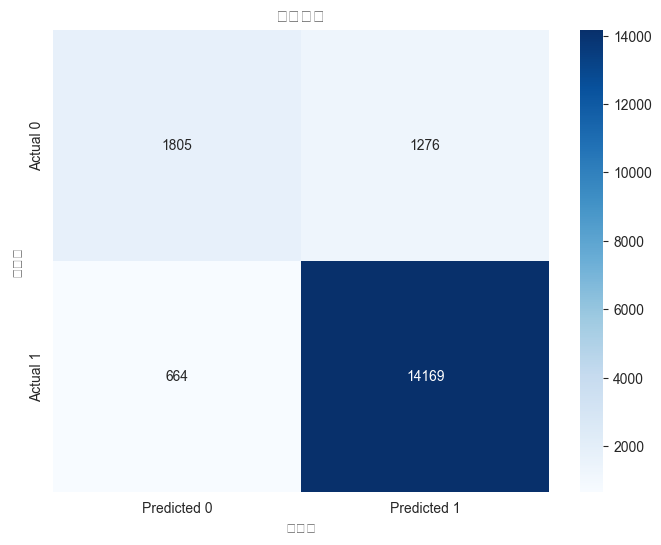

In [104]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 预测
y_pred = clf.predict(X)

# 输出准确率
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f"模型的准确率: {accuracy:.4f}")
print(f"模型的精确率: {precision:.4f}")
print(f"模型的召回率: {recall:.4f}")
print(f"模型的F1分数: {f1:.4f}")

# 构建混淆矩阵
cm = confusion_matrix(y, y_pred)

# 打印混淆矩阵
print("混淆矩阵：")
print(cm)

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('实际值')
plt.xlabel('预测值')
plt.title('混淆矩阵')
plt.show()



模型的准确率: 0.8610
模型的精确率: 0.8746
模型的召回率: 0.9810
模型的F1分数: 0.9247
混淆矩阵：
[[  506  8871]
 [ 1201 61879]]


C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Program

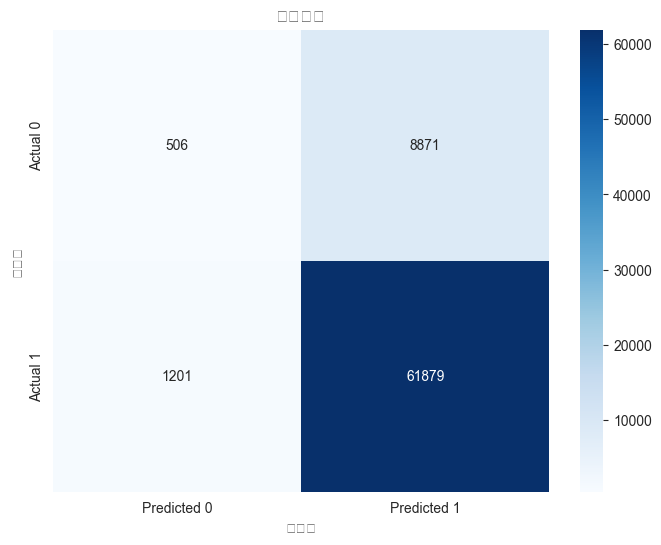

In [88]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # 用于加载已保存的模型

# 假设你已经有一个保存的模型文件 'model.pkl'
# 加载训练好的模型
clf = joblib.load('radiation_dctree.pkl')  # 根据你的模型文件路径进行加载
X = X.rename(columns={
    'contradiction_flag': 'contradict_flag',
    'score_of_contradiction': 'score_of_contradict'
})

# 预测
y_pred = clf.predict(X)

# 输出准确率
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f"模型的准确率: {accuracy:.4f}")
print(f"模型的精确率: {precision:.4f}")
print(f"模型的召回率: {recall:.4f}")
print(f"模型的F1分数: {f1:.4f}")

# 构建混淆矩阵
cm = confusion_matrix(y, y_pred)

# 打印混淆矩阵
print("混淆矩阵：")
print(cm)

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('实际值')
plt.xlabel('预测值')
plt.title('混淆矩阵')
plt.show()


In [13]:
# 模型保存与加载
import pickle

# 假设你的模型是 clf
with open('radiation_dctree_qwen.pkl', 'wb') as file:
    pickle.dump(clf, file)


In [55]:
import pickle
import numpy as np

# 1. 使用 pickle 加载模型
with open('D:/PycharmProjects/TDFilter/tool/DecisionTree/science_dctree.pkl', 'rb') as file:
    clf_loaded = pickle.load(file)

# 2. 构造要预测的数据
# 新的数据，reasonable_score=1 和 conflict_score=1
X_new = np.array([[0.5, 0.5]])  # 这里构建一个二维数组，每个特征对应 reasonable_score 和 conflict_score

# 3. 使用加载的模型进行预测
y_pred = clf_loaded.predict(X_new)

# 4. 输出预测结果
print(f"预测结果: {y_pred[0]}")
print(np.__version__)

C:\Users\Administrator\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 2 features, but DecisionTreeClassifier is expecting 4 features as input.

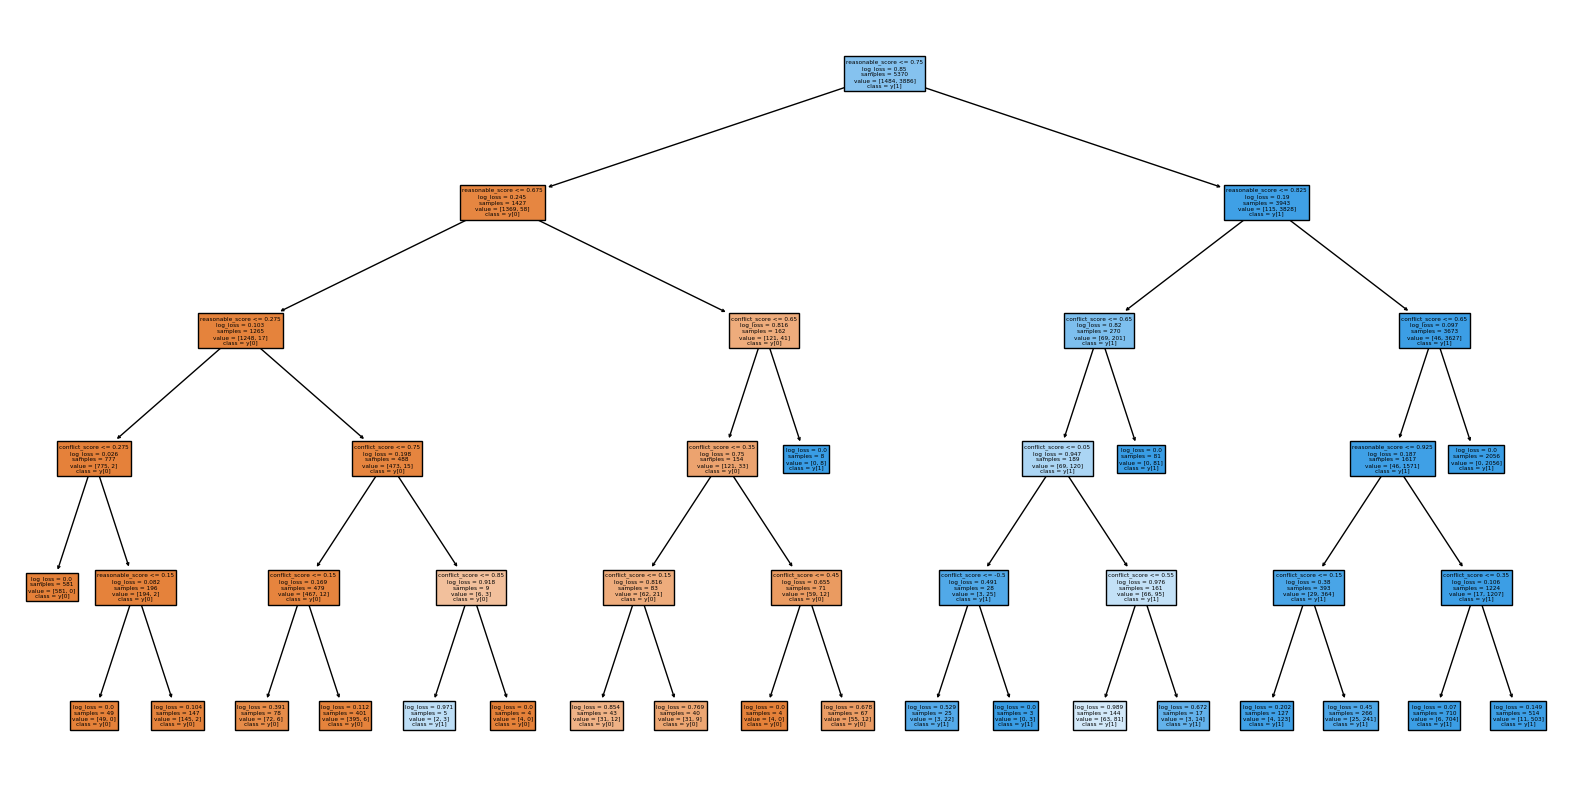

In [7]:
import pickle
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. 使用 pickle 加载决策树模型
with open('model.pkl', 'rb') as file:
    clf_loaded = pickle.load(file)

# 2. 可视化决策树
plt.figure(figsize=(20, 10))  # 设置图像大小
plot_tree(clf_loaded, filled=True, feature_names=['reasonable_score', 'conflict_score'], class_names=True)

# 3. 保存决策树为高清图片，增加 DPI 提高清晰度
plt.savefig('decision_tree_visualization_hd.png', format='png', bbox_inches='tight', dpi=600)

# 4. 显示可视化的决策树
plt.show()


In [21]:
import weka.core.jvm as jvm
import weka.core.converters as converters
import weka.classifiers as classifiers
import pandas as pd
from sklearn.model_selection import train_test_split
from weka.core.dataset import create_instances_from_matrices

# 启动 Java 虚拟机
jvm.start()

# 假设你的 JSON 文件是一个逐行存储的文件，例如 'data.json'
json_file = 'D:/PycharmProjects/TDFilter/experiment5/roberta/Science/results.jsonl'

# 读取 JSON 数据
df = pd.read_json(json_file, lines=True)

# 查看数据大小
print(f"数据集的大小: {len(df)}")

# 提取有用的特征
X = df[['confidence_flag', 'score_of_confidence', 'contradiction_flag', 'score_of_contradiction']].values
y = df['flag'].values  # 目标标签

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50, random_state=42)

# 使用 pandas DataFrame 构造 ARFF 格式所需的矩阵
train_data = create_instances_from_matrices(X_train, y_train)
test_data = create_instances_from_matrices(X_test, y_test)

# 设置类别索引
train_data.class_is_last()
test_data.class_is_last()

# 创建 J48 (C4.5) 分类器
cls = classifiers.Classifier(classname="weka.classifiers.trees.J48")

# 训练模型
cls.build_classifier(train_data)

# 进行预测并评估模型
predictions = []
for index, inst in enumerate(test_data):
    pred = cls.classify_instance(inst)
    predictions.append(pred)

# 计算模型准确率
correct_predictions = sum(1 for i in range(len(predictions)) if predictions[i] == test_data.get_instance(i).get_value(test_data.class_index))
accuracy = correct_predictions / len(predictions)
print(f"模型的准确率: {accuracy:.2f}")

# 停止 Java 虚拟机
jvm.stop()


DEBUG:weka.core.jvm:Adding bundled jars
DEBUG:weka.core.jvm:Classpath=['C:\\Users\\Administrator\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages\\weka\\lib\\arpack_combined.jar', 'C:\\Users\\Administrator\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages\\weka\\lib\\core.jar', 'C:\\Users\\Administrator\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages\\weka\\lib\\mtj.jar', 'C:\\Users\\Administrator\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages\\weka\\lib\\python-weka-wrapper.jar', 'C:\\Users\\Administrator\\AppData\\Local\\Programs\\Python\\Python39\\lib\\site-packages\\weka\\lib\\weka.jar']
DEBUG:weka.core.jvm:MaxHeapSize=default
DEBUG:weka.core.jvm:Package support disabled


JVMNotFoundException: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.

In [20]:
!pip install python-weka-wrapper3


     ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
     --------------------------------------- 0.0/15.9 MB 131.3 kB/s eta 0:02:01
     --------------------------------------- 0.0/15.9 MB 245.8 kB/s eta 0:01:05
     --------------------------------------- 0.0/15.9 MB 245.8 kB/s eta 0:01:05
     --------------------------------------- 0.1/15.9 MB 252.2 kB/s eta 0:01:03
     --------------------------------------- 0.1/15.9 MB 286.7 kB/s eta 0:00:56
     --------------------------------------- 0.1/15.9 MB 291.5 kB/s eta 0:00:55
     --------------------------------------- 0.1/15.9 MB 344.8 kB/s eta 0:00:46
     --------------------------------------- 0.1/15.9 MB 405.9 kB/s eta 0:00:39
     --------------------------------------- 0.2/15.9 MB 464.2 kB/s eta 

In [4]:
def calculate_metrics(confusion_matrix):
    # 提取混淆矩阵的值
    TP = confusion_matrix[0][0]  # 真实正确且预测正确
    TN = confusion_matrix[1][1]  # 真实错误且预测错误
    FP = confusion_matrix[1][0]  # 真实错误但预测正确
    FN = confusion_matrix[0][1]  # 真实正确但预测错误

    # 计算各项指标
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    return {
        'Accuracy': round(accuracy,4),
        'Precision': round(precision,4),
        'Recall': round(recall,4),
        'F1 Score': round(f1_score,4)
    }

# 示例使用
confusion_matrix = [[14545, 288], [940, 2141]]
metrics = calculate_metrics(confusion_matrix)
print(metrics)


{'Accuracy': 0.9315, 'Precision': 0.9393, 'Recall': 0.9806, 'F1 Score': 0.9595}


In [56]:

confusion_matrix = [[60735, 2345], [4236, 5141 ]]
metrics = calculate_metrics(confusion_matrix)
print(metrics)


{'Accuracy': 0.9092, 'Precision': 0.9348, 'Recall': 0.9628, 'F1 Score': 0.9486}


In [65]:
print(63110+6+8810+580)

72506


63116

In [4]:
import json

# 定义转换函数
def convert_text_to_generateKnowledge(data):
    data['generateKnowledge'] = data.pop('text')
    data['flag'] = data.pop('true_flag')
    return data

# 读取JSONL文件并转换
input_file = r'D:\PycharmProjects\TDFilter\DataSet\Radiation\test_dataset93_pretrain.json'  # 替换为你的文件路径
output_file = r'D:\PycharmProjects\TDFilter\DataSet\Radiation\test_dataset93.json'

with open(input_file, 'r', encoding='utf-8') as infile, open(output_file, 'w', encoding='utf-8') as outfile:
    for line in infile:
        json_data = json.loads(line.strip())
        converted_data = convert_text_to_generateKnowledge(json_data)
        outfile.write(json.dumps(converted_data, ensure_ascii=False) + '\n')

print("转换完成，生成的文件保存在:", output_file)


转换完成，生成的文件保存在: D:\PycharmProjects\TDFilter\DataSet\Radiation\test_dataset93.json


In [71]:
13528/(13528+816)

0.9431121026213051

5825

In [1]:
21529+187

21716

In [2]:
4154+12325

16479